БИБЛИОТЕКИ ЗАГРУЖЕНЫ
Seed фиксирован: 42

1. ЗАГРУЗКА ДАННЫХ
Размер датасета: 2468 строк, 11 столбцов

Доступные колонки: ['game_id', 'pot_size', 'num_players', 'has_flop', 'has_turn', 'has_river', 'has_raise', 'has_all_in', 'did_show', 'is_bluff', 'winner']

1.5 ДОБАВЛЕНИЕ КОЛОНКИ hand_odds
Придется добавить колонку hand-odds сгенеренную рандомно, данные про нее не найти в откр доступе
   ОШИБКА: колонка 'cards' не найдена. Создаём hand_odds как случайные значения.

2. ПРЕПРОЦЕССИНГ ДАННЫХ
----------------------------------------
Признаки (9 шт.): ['pot_size', 'num_players', 'has_flop', 'has_turn', 'has_river', 'has_raise', 'has_all_in', 'did_show', 'hand_odds']
Целевая переменная: is_bluff

Проверка пропусков:
pot_size       0
num_players    0
has_flop       0
has_turn       0
has_river      0
has_raise      0
has_all_in     0
did_show       0
hand_odds      0
dtype: int64

Разделение (80/20) с сохранением пропорции классов:
   Обучающая: 1974 раздач
   Тестовая: 494 раздач

Масштаби

C:\Users\foxma\AppData\Local\Temp\ipykernel_6544\2628547521.py:171: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Score', data=results_df, palette='Set2')


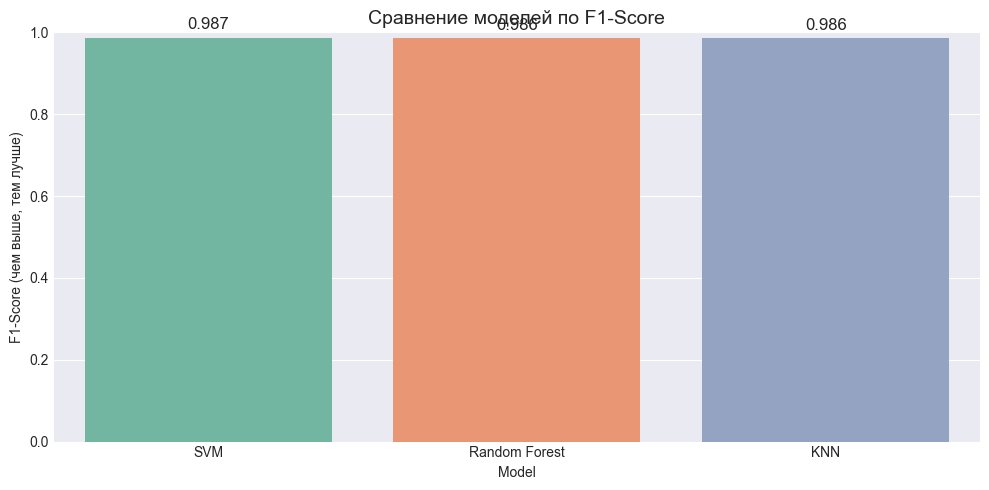


4.GridSearchCV
Поиск лучших параметров для Random Forest...

Лучшие параметры Random Forest:
   {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
   Лучший F1-Score на кросс-валидации: 0.9936

Финальная модель Random Forest обучена
   F1-Score на тесте: 0.9858

5. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ - у нас это получилась RF


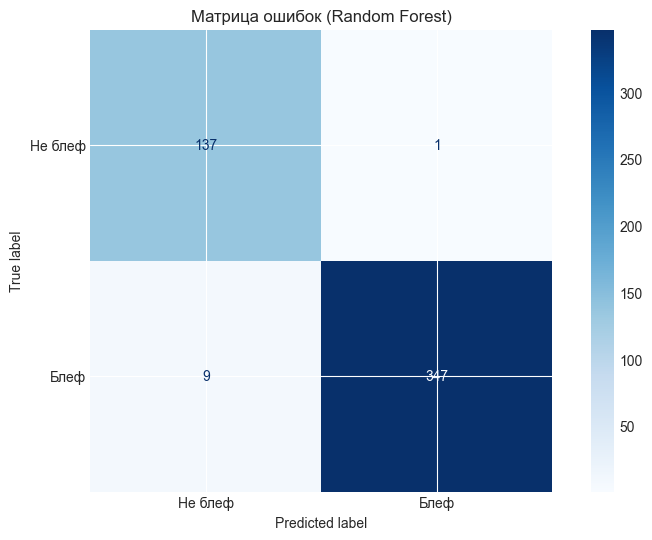


Матрица ошибок:
   True Negatives (правильно не блеф): 137
   False Positives (ложный блеф): 1
   False Negatives (пропущенный блеф): 9
   True Positives (правильно блеф): 347

ВАЖНОСТЬ ПРИЗНАКОВ:
    Feature  Importance
   did_show    0.377110
  has_raise    0.276203
   pot_size    0.167393
  has_river    0.074191
   has_flop    0.063900
   has_turn    0.029190
  hand_odds    0.006506
num_players    0.005450
 has_all_in    0.000057


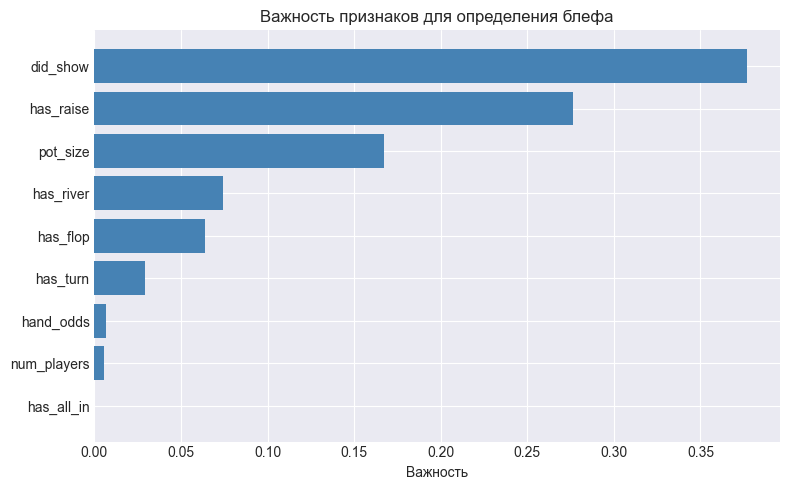

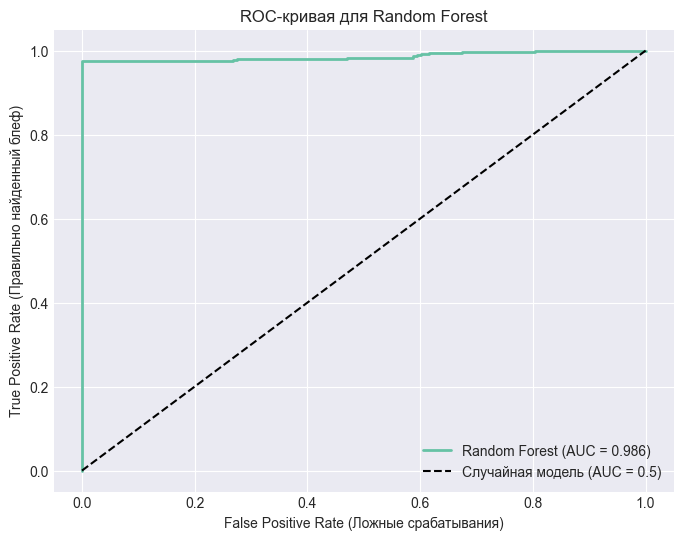


6. АНАЛИЗ СТАРТОВОЙ РУКИ


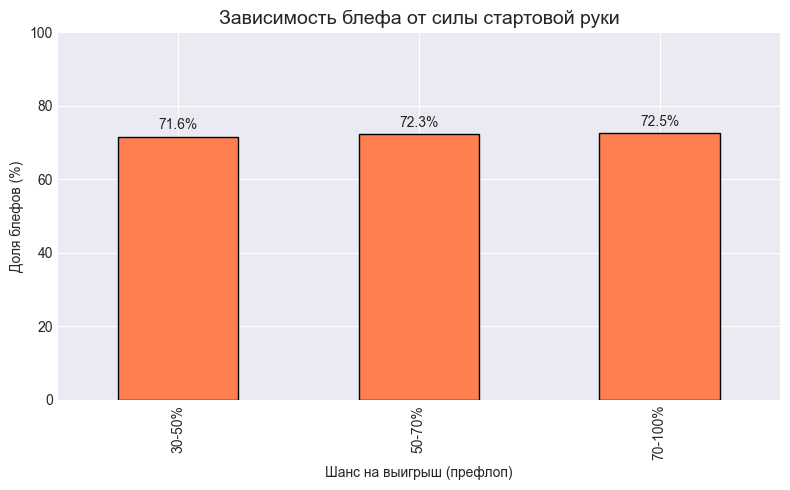


ВЫВОД: Чем слабее рука (меньше шанс на выигрыш), тем чаще игроки блефуют.

7. ИТОГОВЫЕ ВЫВОДЫ

РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ:
   SVM: F1-Score = 0.9872, ROC-AUC = 0.9944
   Random Forest: F1-Score = 0.9858, ROC-AUC = 0.9894
   KNN: F1-Score = 0.9858, ROC-AUC = 0.9852

ЛУЧШАЯ МОДЕЛЬ: Random Forest
   F1-Score: 0.9858
   ROC-AUC: 0.9863

КЛЮЧЕВЫЕ ВЫВОДЫ:
   1. Random Forest показал лучший результат благодаря способности работать с разнородными признаками
   2. hand_odds (шанс руки) является важным признаком — сила руки влияет на блеф
   3. did_show и has_raise — ключевые индикаторы блефа

ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ДЛЯ ПОКЕРИСТОВ:
   - Слабые руки (шанс < 50%) — оптимальны для блефа
   - Сильные руки (шанс > 70%) — лучше разыгрывать честно

ВОСПРОИЗВОДИМОСТЬ:
 мы зафиксировали сид 42


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)

SEED = 42
np.random.seed(SEED)

print("БИБЛИОТЕКИ ЗАГРУЖЕНЫ")
print(f"Seed фиксирован: {SEED}")



print("\n1. ЗАГРУЗКА ДАННЫХ")


df = pd.read_csv('poker_data_improved.csv')

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nДоступные колонки: {df.columns.tolist()}")


print("\n1.5 ДОБАВЛЕНИЕ КОЛОНКИ hand_odds")


if 'hand_odds' not in df.columns:
    print("Придется добавить колонку hand-odds сгенеренную рандомно, данные про нее не найти в откр доступе")
    
    def normalize_hand(cards):
        if pd.isna(cards) or cards == '--':
            return None
        matches = re.findall(r'([2-9TJQKA])([a-z])', str(cards))
        if len(matches) != 2:
            return None
        r1, s1 = matches[0]
        r2, s2 = matches[1]
        if r1 == r2:
            return r1 + r1
        rank_order = '23456789TJQKA'
        if rank_order.index(r1) < rank_order.index(r2):
            r1, r2, s1, s2 = r2, r1, s2, s1
        is_suited = (s1 == s2)
        hand = r1 + r2
        if is_suited:
            hand += 's'
        else:
            hand += 'o'
        return hand
    
    hand_odds_dict = {
        'AA': 85.0, 'KK': 82.0, 'QQ': 80.0, 'JJ': 77.0, 'TT': 75.0,
        '99': 72.0, '88': 69.0, '77': 66.0, '66': 63.0, '55': 60.0,
        '44': 57.0, '33': 54.0, '22': 51.0,
        'AKs': 67.0, 'AQs': 66.0, 'AJs': 65.0, 'ATs': 64.0, 'A9s': 63.0,
        'KQs': 64.0, 'KJs': 63.0, 'KTs': 62.0, 'QJs': 62.0, 'JTs': 61.0,
        'T9s': 57.0, '98s': 56.0, '87s': 55.0, '76s': 54.0, '65s': 53.0,
        'AKo': 65.0, 'AQo': 64.0, 'AJo': 63.0, 'ATo': 62.0, 'KQo': 62.0,
        'KJo': 61.0, 'KTo': 60.0, 'QJo': 60.0, 'JTo': 59.0, 'T9o': 55.0,
    }
    
    if 'cards' in df.columns:
        df['hand_code'] = df['cards'].apply(normalize_hand)
        df['hand_odds'] = df['hand_code'].map(hand_odds_dict)
        mean_odds = df['hand_odds'].mean()
        df['hand_odds'] = df['hand_odds'].fillna(mean_odds)
        print(f"   Колонка hand_odds добавлена. Среднее значение: {mean_odds:.1f}%")
    else:
        print("   ОШИБКА: колонка 'cards' не найдена. Создаём hand_odds как случайные значения.")
        np.random.seed(SEED)
        df['hand_odds'] = np.random.uniform(30, 80, len(df))
else:
    print(f"Колонка hand_odds уже существует. Среднее значение: {df['hand_odds'].mean():.1f}%")


print("\n2. ПРЕПРОЦЕССИНГ ДАННЫХ")
print("-"*40)

features = ['pot_size', 'num_players', 'has_flop', 'has_turn', 'has_river', 
            'has_raise', 'has_all_in', 'did_show', 'hand_odds']

missing_features = [f for f in features if f not in df.columns]
if missing_features:
    print(f"ВНИМАНИЕ: Отсутствуют колонки: {missing_features}")
    features = [f for f in features if f in df.columns]

X = df[features]
y = df['is_bluff']

print(f"Признаки ({len(features)} шт.): {features}")
print(f"Целевая переменная: is_bluff")
print(f"\nПроверка пропусков:")
print(X.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\nРазделение (80/20) с сохранением пропорции классов:")
print(f"   Обучающая: {X_train.shape[0]} раздач")
print(f"   Тестовая: {X_test.shape[0]} раздач")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nМасштабирование выполнено (StandardScaler)")


print("\n3. ОБУЧЕНИЕ И СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*60)

models = {
    'SVM': SVC(kernel='rbf', random_state=SEED, probability=True),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'KNN': KNeighborsClassifier()
}

results = []
predictions = {}

for name, model in models.items():
    print(f"\n{'─'*40}")
    print(f"ОБУЧЕНИЕ: {name}")
    print(f"{'─'*40}")
    
    if name in ['SVM', 'KNN']:
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train
        X_te = X_test
    
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0
    
    results.append({'Model': name, 'F1-Score': f1, 'ROC-AUC': auc})
    predictions[name] = y_pred
    
    print(f"   Обучение завершено")
    print(f"   F1-Score: {f1:.4f}")
    if auc:
        print(f"   ROC-AUC: {auc:.4f}")
    print(f"\n   Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Не блеф', 'Блеф']))

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА")

print(results_df.to_string(index=False))

plt.figure(figsize=(10,5))
sns.barplot(x='Model', y='F1-Score', data=results_df, palette='Set2')
plt.title('Сравнение моделей по F1-Score', fontsize=14)
plt.ylabel('F1-Score (чем выше, тем лучше)')
plt.ylim(0, 1)
for i, row in results_df.iterrows():
    plt.text(i, row['F1-Score'] + 0.02, f"{row['F1-Score']:.3f}", ha='center', fontsize=12)
plt.tight_layout()
plt.show()


print("\n4.GridSearchCV")
print("="*60)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

print("Поиск лучших параметров для Random Forest...")
grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    param_grid_rf,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f"\nЛучшие параметры Random Forest:")
print(f"   {grid_rf.best_params_}")
print(f"   Лучший F1-Score на кросс-валидации: {grid_rf.best_score_:.4f}")

best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print(f"\nФинальная модель Random Forest обучена")
print(f"   F1-Score на тесте: {f1_score(y_test, y_pred_best):.4f}")


print("\n5. АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ - у нас это получилась RF")


cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Не блеф', 'Блеф'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок (Random Forest)')
plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"\nМатрица ошибок:")
print(f"   True Negatives (правильно не блеф): {tn}")
print(f"   False Positives (ложный блеф): {fp}")
print(f"   False Negatives (пропущенный блеф): {fn}")
print(f"   True Positives (правильно блеф): {tp}")

importances = best_rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nВАЖНОСТЬ ПРИЗНАКОВ:")
print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='steelblue')
plt.xlabel('Важность')
plt.title('Важность признаков для определения блефа')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob_best)
auc = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель (AUC = 0.5)')
plt.xlabel('False Positive Rate (Ложные срабатывания)')
plt.ylabel('True Positive Rate (Правильно найденный блеф)')
plt.title('ROC-кривая для Random Forest')
plt.legend()
plt.grid(True)
plt.show()


print("\n6. АНАЛИЗ СТАРТОВОЙ РУКИ")

if 'hand_odds' in df.columns and 'is_bluff' in df.columns:
    df['odds_bucket'] = pd.cut(df['hand_odds'], bins=[0, 30, 50, 70, 100], 
                                labels=['0-30%', '30-50%', '50-70%', '70-100%'])
    
    bluff_by_odds = df.groupby('odds_bucket', observed=True)['is_bluff'].mean() * 100
    
    plt.figure(figsize=(8,5))
    bluff_by_odds.plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Зависимость блефа от силы стартовой руки', fontsize=14)
    plt.xlabel('Шанс на выигрыш (префлоп)')
    plt.ylabel('Доля блефов (%)')
    plt.ylim(0, 100)
    for i, v in enumerate(bluff_by_odds):
        plt.text(i, v + 2, f"{v:.1f}%", ha='center')
    plt.tight_layout()
    plt.show()
    
    print("\nВЫВОД: Чем слабее рука (меньше шанс на выигрыш), тем чаще игроки блефуют.")
    
    if 'hand_code' in df.columns:
        bluff_efficiency = df[df['is_bluff']==1].groupby('hand_code').agg(
            avg_pot=('pot_size', 'mean'),
            bluff_count=('is_bluff', 'count'),
            avg_odds=('hand_odds', 'mean')
        ).sort_values('avg_pot', ascending=False)
        
        print("\nТОП-5 РУК ДЛЯ ВЫГОДНОГО БЛЕФА (по среднему банку):")
        print(bluff_efficiency.head(5)[['avg_pot', 'bluff_count', 'avg_odds']].to_string())
        
        print("\nТОП-5 РУК ДЛЯ ПРОИГРЫШНОГО БЛЕФА (стоит избегать):")
        print(bluff_efficiency.tail(5)[['avg_pot', 'bluff_count', 'avg_odds']].to_string())
else:
    print("Недостаточно данных для анализа стартовой руки (нет hand_odds или is_bluff)")
print("\n7. ИТОГОВЫЕ ВЫВОДЫ")
print("="*60)
print(f"\nРЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ:")
for _, row in results_df.iterrows():
    print(f"   {row['Model']}: F1-Score = {row['F1-Score']:.4f}, ROC-AUC = {row['ROC-AUC']:.4f}")

print(f"\nЛУЧШАЯ МОДЕЛЬ: Random Forest")
print(f"   F1-Score: {f1_score(y_test, y_pred_best):.4f}")
print(f"   ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

print(f"\nКЛЮЧЕВЫЕ ВЫВОДЫ:")
print(f"   1. Random Forest показал лучший результат благодаря способности работать с разнородными признаками")
if 'hand_odds' in df.columns:
    print(f"   2. hand_odds (шанс руки) является важным признаком — сила руки влияет на блеф")
print(f"   3. did_show и has_raise — ключевые индикаторы блефа")

print(f"\nПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ ДЛЯ ПОКЕРИСТОВ:")
print(f"   - Слабые руки (шанс < 50%) — оптимальны для блефа")
print(f"   - Сильные руки (шанс > 70%) — лучше разыгрывать честно")

print(f"\nВОСПРОИЗВОДИМОСТЬ:")
print(f" мы зафиксировали сид 42")

